# A tour of the STARfinder registration module

This notebook introduces the registration module of the maintained Python package
(`starfinder.registration`, with its recipe in `starfinder.dataset` and its metrics in
`starfinder.evaluation.registration`). It shows how the pieces fit together and how they
are checked, by running them on synthetic scenes whose displacement is known exactly:

1. the architecture and conventions: stages, methods, recipes and steps, the method
   registries, the pull convention and index versus physical space;
2. registration pairs with known truth;
3. the seven registered methods, one by one, through `estimate_transform`;
4. recipes, transform chains and the one final resampling;
5. routine QC, rejection and recovery;
6. one field of view (FOV) through `FOV.run`, with its records and a reloaded checkpoint;
7. registration of other rounds from a shared stain, and of an external reference;
8. how the module is checked, and its known limits.

Every section explains a design choice first and then runs the code that shows it. The
design itself is documented in `docs/`; this notebook links those pages rather than
repeating them. The notebook explains and demonstrates the design. **It is not a
benchmark:** each method runs once, with its default parameters, on one synthetic scene
and one seed, so the error tables below describe this demonstration only and do not rank
the methods or recommend a default.

**Scope and resources.** The scenes are generated in memory from the `small` benchmark
preset and never exceed its size. The notebook needs no downloaded data, MATLAB, GPU or
network access, but it does need the optional `registration-elastix` and
`local-registration` extras (elastix and SimpleITK). Every random draw comes from a fixed
seed and the numerical libraries run on one thread, so a second execution prints the same
numbers on the same host and library build. Files are written only under a temporary
directory that the notebook creates and removes in its last cell. A full execution takes
a few minutes on one CPU thread.

To execute it from `src/python` in a locked environment that includes the `dev` group
(which provides Jupyter) and the two extras:

```bash
uv run jupyter nbconvert --to notebook --execute --output-dir <new directory> \
    ../../example/introduction/starfinder_registration_tour.ipynb
```

The setup cell draws figures inline and keeps numerical libraries on one thread (set
before NumPy is imported). It checks that `starfinder` is imported from the checkout that
holds this notebook, and that importing the registration module does not import the
optional backends: elastix (`itk`) and SimpleITK are imported only when a method that
needs them runs. The cell then imports both backends and sets their global thread counts
to one, so every estimate below is single-threaded and repeatable. The helper `rel` prints
paths relative to the temporary workspace, and `show` prints an object's summary with the
workspace written as `<workspace>`, so no machine-specific path appears in the output.

In [1]:
%matplotlib inline
import os

for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS",
                 "ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"):
    os.environ.setdefault(variable, "1")

import sys
import json
import tempfile
from dataclasses import asdict, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import starfinder
import starfinder.dataset
import starfinder.evaluation.registration
import starfinder.registration

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 80)

REPOSITORY = Path(starfinder.__file__).resolve().parents[3]
print("starfinder imported from:", Path(starfinder.__file__).resolve().relative_to(REPOSITORY).as_posix())
print("the same checkout as this notebook:", Path.cwd().resolve().is_relative_to(REPOSITORY))
print("backends imported by the registration module:",
      {name: name in sys.modules for name in ("itk", "SimpleITK")})

import itk
import SimpleITK as sitk

itk.MultiThreaderBase.SetGlobalDefaultNumberOfThreads(1)
sitk.ProcessObject.SetGlobalDefaultNumberOfThreads(1)
print("ITK and SimpleITK global threads:", itk.MultiThreaderBase.GetGlobalDefaultNumberOfThreads(),
      sitk.ProcessObject.GetGlobalDefaultNumberOfThreads())

_workspace = tempfile.TemporaryDirectory(prefix="starfinder-registration-tour-")
WORKSPACE = Path(_workspace.name)


def rel(path):
    # Show a path relative to the temporary workspace.
    return Path(path).relative_to(WORKSPACE).as_posix()


def show(obj):
    # Print an object's summary with the workspace written as <workspace>.
    print(repr(obj).replace(str(WORKSPACE), "<workspace>"))


print("workspace: a new temporary directory; it is removed at the end")

starfinder imported from: src/python/starfinder/__init__.py
the same checkout as this notebook: True
backends imported by the registration module: {'itk': False, 'SimpleITK': False}


ITK and SimpleITK global threads: 1 1
workspace: a new temporary directory; it is removed at the end


## 1. Architecture and conventions

**Terms.** The registration design uses four words with fixed meanings
([docs/registration-contract.md](../../docs/registration-contract.md#terms)):

* a **stage** is a pipeline stage: preprocessing, registration, spot finding;
* a **method** is a registrable algorithm of a stage, such as `affine`;
* a **recipe** is a stage's ordered configuration, such as `RegistrationRecipe`;
* a **step** is one position in a recipe, and names a method. Recipe positions are never
  called stages.

**Registries.** Each stage owns one plain dictionary from an *exact* frozen config type to
a frozen spec that declares the method's stable name and capabilities
([docs/method-registry.md](../../docs/method-registry.md)). Everything that needs the set
of methods (`estimate_transform`, the recipe validation, the workflow adapter, the
checkpoint reader, the benchmark adapter) derives it from the registry, so there is no
second list to keep in step. Lookup uses the exact type: a subclass of a config is not a
registered method. For registration the spec adds four capabilities:

* `step_kind`: `global` (translation, rigid, affine) or `local` (a deformation); a recipe
  is zero or more global steps followed by at most one local step;
* `dimensions`: `2` when a Z=1 input is estimated as genuine 2D, `3` when Z>1 is
  estimated in 3D;
* `transform_kind`: the kind of transform the method returns;
* `space`: whether estimation runs on voxel indices (`index`) or on physical coordinates
  from the voxel spacing (`physical`).

`requires` lists optional dependencies with the extra that installs them; they are
imported only when the method runs. `min_shape_zyx` is the smallest accepted size of each
axis. The next cell prints the registration registry as a table.

In [2]:
from importlib import metadata

from starfinder.registration import REGISTRATION_METHODS


def installed(distribution):
    try:
        return metadata.version(distribution)
    except metadata.PackageNotFoundError:
        return "not installed"


registry = pd.DataFrame([dict(
    name=spec.name,
    config=config_type.__name__,
    step_kind=spec.step_kind,
    dimensions=", ".join(f"{d}D" for d in sorted(spec.dimensions)),
    transform_kind=spec.transform_kind,
    space=spec.space,
    min_shape_zyx=spec.min_shape_zyx,
    requires=", ".join(f"{d.distribution} [{d.extra}] {installed(d.distribution)}" for d in spec.requires) or "none",
) for config_type, spec in REGISTRATION_METHODS.items()])
registry

,name,config,step_kind,dimensions,transform_kind,space,min_shape_zyx,requires
0,translation,TranslationConfig,global,"2D, 3D",translation,index,"(1, 1, 1)",none
1,rigid,RigidConfig,global,"2D, 3D",affine,physical,"(4, 16, 16)",itk-elastix [registration-elastix] 0.25.4
2,affine,AffineConfig,global,"2D, 3D",affine,physical,"(4, 16, 16)",itk-elastix [registration-elastix] 0.25.4
3,bspline,BSplineConfig,local,"2D, 3D",bspline,physical,"(4, 16, 16)","itk-elastix [registration-elastix] 0.25.4, SimpleITK [local-registration] 2.5.3"
4,demons,DemonsConfig,local,"2D, 3D",dense,index,"(4, 4, 4)",SimpleITK [local-registration] 2.5.3
5,tps,TpsConfig,local,3D,dense,index,"(2, 2, 2)",none
6,cpd,CpdConfig,local,3D,dense,index,"(2, 2, 2)",none


The preprocessing stage has the same shape of registry, `PREPROCESSING_METHODS`, with its
own capabilities (category, scope, dtype policy, whether a step may run after
registration and whether it can use supplied statistics). Spot finding has one too,
`SPOT_FINDING_METHODS` (see the spot-finding tour): its methods are listed below with the
`pipeline` capability, which says whether `PipelineConfig.spot_finding`, the pipeline's
spot-finding field, accepts the method, and the cell asks `PipelineConfig` about one
pipeline and one landmark config.

In [3]:
import starfinder.spot_finding as spot_finding
from starfinder.dataset import PipelineConfig
from starfinder.preprocessing import PREPROCESSING_METHODS

preprocessing = pd.DataFrame([dict(
    name=spec.name, config=config_type.__name__, category=spec.category, scope=spec.scope,
    dtype_policy=spec.dtype_policy, post_registration=spec.post_registration,
    supplied_statistics=spec.supplied is not None,
    requires=", ".join(f"{d.distribution} [{d.extra}]" for d in spec.requires) or "none",
) for config_type, spec in PREPROCESSING_METHODS.items()])
print("PREPROCESSING_METHODS")
print(preprocessing.to_string(index=False))


def pipeline_accepts(config):
    try:
        PipelineConfig(spot_finding=config)
        return True
    except TypeError:
        return False


print("\nSPOT_FINDING_METHODS")
print(pd.DataFrame([dict(method=spec.name, config=config_type.__name__, pipeline=spec.pipeline)
                    for config_type, spec in spot_finding.SPOT_FINDING_METHODS.items()]).to_string(index=False))
for config in (spot_finding.LocalMaximaConfig(), spot_finding.NoiseLandmarkConfig()):
    print(f"PipelineConfig(spot_finding={type(config).__name__}()) accepted:", pipeline_accepts(config))

PREPROCESSING_METHODS
                    name                        config   category           scope dtype_policy  post_registration  supplied_statistics requires
   min_max_normalization     MinMaxNormalizationConfig  intensity     per_channel     declared              False                False     none
      histogram_matching       HistogramMatchingConfig  intensity needs_reference     preserve              False                 True     none
          reconstruction          ReconstructionConfig background     per_channel     preserve               True                False     none
            white_tophat                  TophatConfig background     per_channel     preserve              False                False     none
       scalar_background        ScalarBackgroundConfig background     per_channel     preserve              False                 True     none
           background_3d            Background3DConfig background     per_channel     preserve              False 

**The pull convention.** Every transform is a *pull* map from reference coordinates to
moving coordinates: the registered image at reference index `p` is the moving image
sampled at `T(p)`. Indices are 0-based **ZYX** voxel indices, and the reference and moving
grids must be equal (same shape, spacing, origin, direction and unit); nothing is
rescaled or inferred. The four transform types and the chain that composes them keep
their direction and units as explicit fields, and a transform with any other direction or
units is rejected, so nothing is ever inverted or converted implicitly. The translation
follows the same convention: it stores the detected displacement `d` of the moving
content, `T(p) = p + d`, so the number the estimator reports is the number the transform
applies, the composition adds and the shift log records.

**Index versus physical space.** Translation, demons, TPS and CPD estimate on voxel
indices. Rigid, affine and B-spline estimate on physical coordinates built from
`ImageMetadata.spacing_zyx` (so a rotation stays rigid for anisotropic voxels) and are
stored in index space: the affine as a homogeneous index matrix with the physical parameters kept
beside it, the B-spline as its physical control grid. When the spacing is unknown on both
images, estimation uses unit spacing and records that choice. The next cell prints each
type's direction, units and pull map, taken from the classes themselves, and then
applies a translation to a small ramp to show the convention at one voxel.

In [4]:
from dataclasses import fields as dataclass_fields

from starfinder.image import ImageMetadata
from starfinder.registration import (AffineTransform, BSplineTransform, DenseDisplacementTransform,
                                     TransformChain, TranslationTransform, WarpConfig, apply_transform)


def default(cls, name):
    return next(f.default for f in dataclass_fields(cls) if f.name == name)


types = pd.DataFrame([dict(type=cls.__name__, direction=default(cls, "direction"), units=default(cls, "units"),
                           summary=cls.__doc__.strip().splitlines()[0])
                      for cls in (TranslationTransform, AffineTransform, BSplineTransform,
                                  DenseDisplacementTransform, TransformChain)])
print(types.to_string(index=False))

ramp_shape = (4, 8, 8)
ramp = np.arange(np.prod(ramp_shape), dtype=np.float64).reshape(ramp_shape)
grid = dict(reference_shape_zyx=ramp_shape, moving_shape_zyx=ramp_shape,
            reference_metadata=ImageMetadata("demo/reference"), moving_metadata=ImageMetadata("demo/moving"))
shift = TranslationTransform((1.0, -2.0, 3.0), **grid)
registered = apply_transform(ramp, shift, config=WarpConfig(output_dtype="float64"))
p = (2, 3, 4)
source = tuple(int(v + d) for v, d in zip(p, shift.displacement_zyx))
print(f"\ndisplacement d = {shift.displacement_zyx}: registered[p = {p}] = {registered[p]:g} "
      f"= moving[p + d = {source}] = {ramp[source]:g}")

                      type           direction       units                                                                      summary
      TranslationTransform reference_to_moving voxel_index         Compact pull map: moving index = reference index + displacement_zyx.
           AffineTransform reference_to_moving voxel_index Linear pull map: moving index = A @ reference index + b (ZYX voxel indices).
          BSplineTransform reference_to_moving voxel_index     Cubic B-spline pull map on a physical control grid: p + S^-1 P v(P S p).
DenseDisplacementTransform reference_to_moving voxel_index        Pull field: moving index = reference index + displacement_zyx[index].
            TransformChain reference_to_moving voxel_index The ordered step transforms of one moving round, composed into one pull map.

displacement d = (1.0, -2.0, 3.0): registered[p = (2, 3, 4)] = 207 = moving[p + d = (3, 1, 7)] = 207


**Where the accepted pages live.** The design is specified in four accepted pages; the
cell prints their titles from the files. The method registry across stages is
[docs/method-registry.md](../../docs/method-registry.md); the recipe, transforms,
composition, persistence, QC, records and workflow keys are in
[docs/registration-contract.md](../../docs/registration-contract.md); the numerical rules
of rigid, affine, B-spline and 2D demons and the engineering validation design are in
[docs/registration-algorithms.md](../../docs/registration-algorithms.md); and the behavior
before this work, with the golden test, is in
[docs/registration-baseline.md](../../docs/registration-baseline.md).

In [5]:
for page in ("method-registry", "registration-contract", "registration-algorithms", "registration-baseline"):
    path = REPOSITORY / "docs" / f"{page}.md"
    print(f"docs/{page}.md: {path.read_text().splitlines()[0].lstrip('# ')}")

docs/method-registry.md: Method registry across stages
docs/registration-contract.md: Registration recipe contract
docs/registration-algorithms.md: Registration algorithm specification
docs/registration-baseline.md: Registration baseline


## 2. Registration pairs with known truth

A registration pair is two rounds of the same formed scene, a reference round and a moving
round, in which only the moving round is moved
([docs/synthetic-specification.md](../../docs/synthetic-specification.md)). The generator
maps each reference point `q` of the moving round to `F(q)`, a composition of a
translation, a linear term, a smooth quadratic term and local Gaussian displacements, and
it renders the moving round by sampling the molecules and background analytically at
`F⁻¹` (no image interpolation). `F` is recorded in the scene's transforms, and
`forward_displacement` evaluates `F(q) − q` on every reference voxel. That is exactly the
pull displacement an ideal registration would return, so it is the truth that every
estimate below is compared with.

`generate_registration_pair` builds one pair of a benchmark preset in one call, with the
preset's benchmark appearance (brightness, widths, crosstalk, background and noise) and
either a translation (`shift`) or one of `DEFORMATION_PRESETS`. The amplicon signal is in
channel `ch00`; the other channels carry background, crosstalk and noise.

In [6]:
from starfinder.synthetic import DEFORMATION_PRESETS, forward_displacement, generate_registration_pair

DEFORMATION = "polynomial_small"
print("DEFORMATION_PRESETS:")
for name, spec in DEFORMATION_PRESETS.items():
    print(f"  {name:<17} {spec}")

pair = generate_registration_pair("small", deformation=DEFORMATION)
rounds = pair.rounds["small"]
print("\nrounds:", {label: (image.shape, str(image.dtype)) for label, image in rounds.items()})
print("amplicons:", pair.historical_truth["n_spots"], " seed:", pair.historical_truth["seed"])
print("truth summary:", pair.historical_truth["pairs"])

record = next(t for t in pair.provenance["small"]["transforms"].values() if t["round_label"] == DEFORMATION)
print("translation of the forward map (dz, dy, dx):", record["translation_zyx"])
u_pair = forward_displacement(record, rounds["reference"].shape[:3])
magnitude = np.linalg.norm(u_pair, axis=-1)
print(f"truth |u*| over the grid (voxel): median {np.median(magnitude):.3f}, "
      f"p95 {np.percentile(magnitude, 95):.3f}, max {magnitude.max():.3f}")

DEFORMATION_PRESETS:
  polynomial_small  {'kind': 'polynomial', 'percent': 3.0, 'cap_px': 15.0}
  polynomial_large  {'kind': 'polynomial', 'percent': 6.0, 'cap_px': 30.0}
  gaussian_small    {'kind': 'rbf', 'percent': 3.0, 'radius_percent': 6.0, 'cap_px': 15.0, 'points': 1}
  gaussian_large    {'kind': 'rbf', 'percent': 6.0, 'radius_percent': 10.0, 'cap_px': 30.0, 'points': 1}
  multi_point       {'kind': 'rbf', 'percent': 4.0, 'radius_percent': 5.0, 'cap_px': 20.0, 'points': 4}
  linear_small      {'kind': 'affine', 'percent': 1.0, 'cap_px': 10.0}



rounds: {'reference': ((16, 256, 256, 4), 'uint16'), 'polynomial_small': ((16, 256, 256, 4), 'uint16')}
amplicons: 50  seed: 42
truth summary: {'polynomial_small': {'type': 'local_deformation', 'deformation_type': 'polynomial_small', 'kind': 'polynomial_affine_gaussian_rbf_translation', 'lipschitz_bound': 0.12854838602245716, 'field_file': 'field_polynomial_small.npy'}}
translation of the forward map (dz, dy, dx): [0.0, 0.0, 0.0]
truth |u*| over the grid (voxel): median 1.535, p95 5.420, max 8.174


The one-call pair keeps the preset's sparse amplicon count and has no translation. For the
rest of the notebook the same preset and deformation are built through the functions that
`generate_registration_pair` itself uses (`registration_scene_preset`,
`deformation_geometry` and `generate_formed_scene`), with two changes: more amplicons, so
that the landmark methods (TPS and CPD) find enough landmarks, and a random translation on
top of the deformation, so that the global methods have something to recover. The
deformation magnitude comes from the preset unchanged. This scene is the fixture of
sections 2 to 7.

In [7]:
from starfinder.synthetic import deformation_geometry, generate_formed_scene, registration_scene_preset

codebook, scene_config = registration_scene_preset("small", DEFORMATION)
SHAPE = scene_config.shape_zyx
scene_config = replace(scene_config, count=1000, max_count=1024, geometry=deformation_geometry(
    DEFORMATION, SHAPE, reference_round="reference", translation_max_zyx=(2, 6, 6)))
scene = generate_formed_scene(codebook, config=scene_config)

REFERENCE, MOVING = "reference", DEFORMATION
reference_round, moving_round = scene.rounds[REFERENCE], scene.rounds[MOVING]
reference_metadata, moving_metadata = scene.round_metadata[REFERENCE], scene.round_metadata[MOVING]
transform_record = next(t for t in scene.provenance["transforms"].values() if t["round_label"] == MOVING)
truth = forward_displacement(transform_record, SHAPE)

print("shape (ZYX):", SHAPE, " channels:", scene.channel_labels, " dtype:", reference_round.dtype,
      " amplicons:", len(scene.formed), " seed:", scene_config.seed)
print("forward map:", transform_record["kind"], " translation (dz, dy, dx):",
      np.round(transform_record["translation_zyx"], 3).tolist())
magnitude = np.linalg.norm(truth, axis=-1)
print(f"truth |u*| (voxel): median {np.median(magnitude):.3f}, p95 {np.percentile(magnitude, 95):.3f}, "
      f"max {magnitude.max():.3f}")
print(f"truth Z component (voxel): min {truth[..., 0].min():.3f}, max {truth[..., 0].max():.3f}")

shape (ZYX): (16, 256, 256)  channels: ('ch00', 'ch01', 'ch02', 'ch03')  dtype: uint16  amplicons: 1000  seed: 42
forward map: polynomial_affine_gaussian_rbf_translation  translation (dz, dy, dx): [1.55, -1.891, -2.309]
truth |u*| (voxel): median 3.074, p95 4.610, max 5.760
truth Z component (voxel): min 1.549, max 2.028


The figure shows the maximum projections over Z of `ch00` in both rounds, and the truth
pull displacement in the middle Z plane: its magnitude as a color map and its YX
components as arrows, drawn longer than the displacement by the factor `ARROW_SCALE` for
legibility; the cell prints the factor and the title repeats it.

arrow grid step: 16 voxels; ARROW_SCALE: arrows drawn 4 times the YX displacement


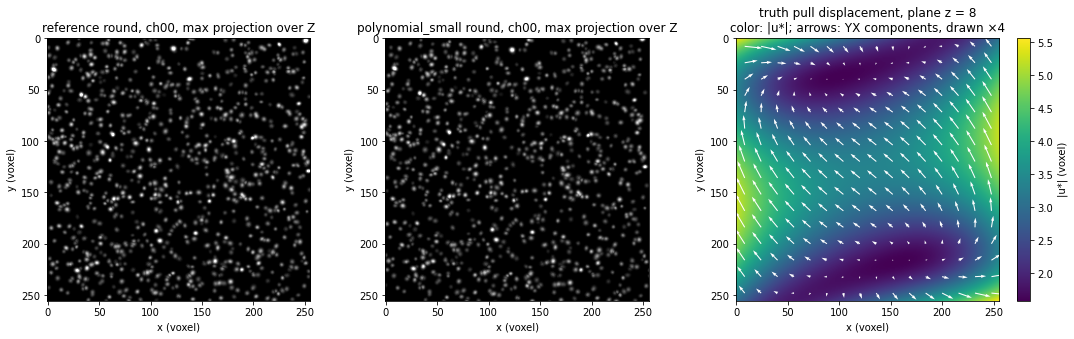

In [8]:
MID = SHAPE[0] // 2
reference_signal = reference_round[..., 0].astype(np.float64)
moving_signal = moving_round[..., 0].astype(np.float64)
display = (np.percentile(reference_signal.max(axis=0), 50), np.percentile(reference_signal.max(axis=0), 99.9))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), dpi=72, constrained_layout=True)
for axis, (label, signal) in zip(axes, ((REFERENCE, reference_signal), (MOVING, moving_signal))):
    axis.imshow(signal.max(axis=0), cmap="gray", vmin=display[0], vmax=display[1])
    axis.set(title=f"{label} round, ch00, max projection over Z", xlabel="x (voxel)", ylabel="y (voxel)")
image = axes[2].imshow(np.linalg.norm(truth[MID], axis=-1), cmap="viridis")
fig.colorbar(image, ax=axes[2], label="|u*| (voxel)")
step = 16
ARROW_SCALE = 4
print(f"arrow grid step: {step} voxels; ARROW_SCALE: arrows drawn {ARROW_SCALE} times the YX displacement")
yy, xx = np.mgrid[step // 2:SHAPE[1]:step, step // 2:SHAPE[2]:step]
axes[2].quiver(xx, yy, truth[MID, yy, xx, 2], truth[MID, yy, xx, 1], color="white",
               angles="xy", scale_units="xy", scale=1 / ARROW_SCALE, width=0.004)
axes[2].set(title=f"truth pull displacement, plane z = {MID}\ncolor: |u*|; arrows: YX components, drawn ×{ARROW_SCALE}",
            xlabel="x (voxel)", ylabel="y (voxel)")
plt.show()

## 3. The methods one by one through `estimate_transform`

`estimate_transform(reference, moving, *, config, reference_metadata, moving_metadata)`
takes two finite float ZYX signals on equal grids and one registered config. The exact
config type selects the method in `REGISTRATION_METHODS`; the method's declared dimensions
and minimum shape are checked, and its optional dependencies imported, *before* it runs.
It returns a `RegistrationResult`: the transform, a `RegistrationDiagnostics` (method,
backend, effective config and whatever the method measures) and the `WarpConfig` that
applies it. Estimation never substitutes another algorithm; a failure raises a typed
error.

Each estimate is compared with the truth by `evaluate_displacement_field`: the
`median_error`, `p95_error` and `max_error` of `|u − u*|` in voxels, where `u` is the estimated pull
displacement (`TransformChain((transform,)).pull_field()` gives it for every transform
type). The comparison is made over the **valid overlap**, the reference voxels whose pull
point lies inside the closed box `[0, n−1]` of the moving grid on every axis; the helper
below computes it with the same definition that `registration_qc` uses (section 5 checks
that they agree). The identity error over the same voxels (the error of doing nothing) is
printed next to it.

The signals are `ch00` of each round as float64; the synthetic metadata has no voxel
spacing, so the physical-space methods use unit spacing and say so.

In [9]:
from starfinder.evaluation.registration import evaluate_displacement_field
from starfinder.registration import estimate_transform


def valid_overlap(u):
    # Reference voxels whose pull point lies inside the closed box [0, n-1] of the moving grid.
    valid = np.ones(u.shape[:3], dtype=bool)
    for axis, n in enumerate(u.shape[:3]):
        index = np.arange(n, dtype=np.float64).reshape([-1 if a == axis else 1 for a in range(3)])
        valid &= (index + u[..., axis] >= 0) & (index + u[..., axis] <= n - 1)
    return valid


def diagnostics_of(result):
    # The measured diagnostics of a result: every field that is set, except the config and backend parameters.
    skip = {"method", "backend", "effective_config", "backend_parameters"}
    out = {}
    for name, value in asdict(result.diagnostics).items():
        if name in skip or value in (None, ()):
            continue
        out[name] = tuple(round(v, 4) if isinstance(v, float) else v for v in value) if isinstance(value, tuple) \
            else value
    return out


RESULTS, ROWS = {}, []


def estimate(label, config, reference=reference_signal, moving=moving_signal, u_truth=truth,
             metadata=(reference_metadata, moving_metadata)):
    # Estimate one method, print its summary and error against the truth, and keep a table row.
    result = estimate_transform(reference, moving, config=config, reference_metadata=metadata[0],
                                moving_metadata=metadata[1])
    u = TransformChain((result.transform,)).pull_field().displacement_zyx
    mask = valid_overlap(u)
    error = evaluate_displacement_field(u, u_truth, mask=mask).values
    identity = evaluate_displacement_field(np.zeros_like(u), u_truth, mask=mask).values
    RESULTS[label] = result
    ROWS.append(dict(method=label, transform=type(result.transform).__name__, backend=result.diagnostics.backend,
                     shape=reference.shape, valid_overlap=mask.mean(), **{k: error[k] for k in error},
                     identity_median=identity["median_error"], identity_p95=identity["p95_error"]))
    print(result)
    print("  config:     ", config)
    print("  transform:  ", type(result.transform).__name__, " application:", result.application_config)
    print("  diagnostics:", diagnostics_of(result))
    print(f"  error vs truth over the valid overlap ({mask.mean():.3f} of the voxels): "
          + ", ".join(f"{k} {v:.3f}" for k, v in error.items())
          + f"   (identity: median {identity['median_error']:.3f}, p95 {identity['p95_error']:.3f})")
    return result

**Translation** (`TranslationConfig`, global, index space). Phase correlation finds the
integer peak of the cross-power spectrum; the result is a `TranslationTransform` that
stores the detected displacement itself. It models only a uniform shift,
so the polynomial deformation remains as error. The detected displacement is the dominant
shift of the scene, which here mixes the drawn translation with the quadratic term; the
cell prints the drawn translation and the mean truth displacement for comparison.

In [10]:
from starfinder.registration import TranslationConfig

translation_result = estimate("translation", TranslationConfig())
print("detected displacement (dz, dy, dx):", list(translation_result.transform.displacement_zyx))
print("drawn translation (dz, dy, dx):    ", np.round(transform_record["translation_zyx"], 3).tolist())
print("mean truth displacement (dz, dy, dx):", np.round(truth.reshape(-1, 3).mean(axis=0, dtype=np.float64), 3).tolist())

RegistrationResult: translation (scipy_fft), displacement_zyx (1, -2, -1)
  config:      TranslationConfig(backend='scipy_fft', fft_workers=1, method='translation')
  transform:   TranslationTransform  application: WarpConfig(backend='translation', boundary_mode='constant', fill_value=0, output_dtype='input', integer_rounding='nearest_even', clip_to_dtype=True, fft_workers=1)
  diagnostics: {}
  error vs truth over the valid overlap (0.927 of the voxels): median_error 1.524, p95_error 4.427, max_error 7.053   (identity: median 3.071, p95 4.593)
detected displacement (dz, dy, dx): [1.0, -2.0, -1.0]
drawn translation (dz, dy, dx):     [1.55, -1.891, -2.309]
mean truth displacement (dz, dy, dx): [1.685, -1.446, -0.894]


**Rigid and affine** (`RigidConfig`, `AffineConfig`, global, physical space, elastix).
Both return an `AffineTransform`: `matrix_zyx` is the homogeneous index-space pull matrix
`[[A, b], [0, 1]]`, and `physical` keeps the backend's own parameters (for rigid, Euler
angles and a translation). elastix runs a fixed number of iterations per pyramid level
with no convergence test, so `converged` stays unknown and the per-level iterations,
final metric values and stop conditions are recorded instead. Each uses its config's
default metric, printed in its config line. Rigid models a rotation and a shift; affine adds
scaling and shear. Neither can model the quadratic term.

In [11]:
from starfinder.registration import AffineConfig, RigidConfig

rigid = estimate("rigid", RigidConfig())
print("  physical parameters:", {k: rigid.transform.physical[k] for k in ("transform", "parameter_names")})
print()
affine = estimate("affine", AffineConfig())
print("  index-space matrix [[A, b], [0, 1]]:")
print(np.array2string(affine.transform.matrix_zyx, precision=4, suppress_small=True))

RegistrationResult: rigid (elastix), affine matrix_zyx
  config:      RigidConfig(metric='mattes', histogram_bins=32, iterations=200, samples=4096, levels=None, random_seed=1, method='rigid')
  transform:   AffineTransform  application: WarpConfig(backend='scipy', boundary_mode='constant', fill_value=0, output_dtype='input', integer_rounding='nearest_even', clip_to_dtype=True, fft_workers=1)
  diagnostics: {'iterations_completed': (200, 200, 200, 200), 'warnings': ("spacing_zyx is unknown; estimated with unit spacing (spacing_source='unknown_unit')",), 'final_metric_value': (-0.8355, -0.49, -0.1995, -0.1319), 'stop_condition': ('Maximum number of iterations has been reached.', 'Maximum number of iterations has been reached.', 'Maximum number of iterations has been reached.', 'Maximum number of iterations has been reached.'), 'backend_versions': {'itk-elastix': '0.25.4', 'itk': '5.4.7'}, 'spacing_source': 'unknown_unit'}
  error vs truth over the valid overlap (0.861 of the voxels): med

RegistrationResult: affine (elastix), affine matrix_zyx
  config:      AffineConfig(metric='ncc', iterations=200, samples=4096, levels=None, random_seed=1, method='affine')
  transform:   AffineTransform  application: WarpConfig(backend='scipy', boundary_mode='constant', fill_value=0, output_dtype='input', integer_rounding='nearest_even', clip_to_dtype=True, fft_workers=1)
  diagnostics: {'iterations_completed': (200, 200, 200, 200), 'warnings': ("spacing_zyx is unknown; estimated with unit spacing (spacing_source='unknown_unit')",), 'final_metric_value': (-0.9168, -0.8526, -0.7399, -0.7424), 'stop_condition': ('Maximum number of iterations has been reached.', 'Maximum number of iterations has been reached.', 'Maximum number of iterations has been reached.', 'Maximum number of iterations has been reached.'), 'backend_versions': {'itk-elastix': '0.25.4', 'itk': '5.4.7'}, 'spacing_source': 'unknown_unit'}
  error vs truth over the valid overlap (0.863 of the voxels): median_error 1.279, 

**B-spline** (`BSplineConfig`, local, physical space, elastix). A B-spline on a physical
control grid. With `grid_spacing_physical=None`, the default, the control spacing is a fixed
fraction of the physical X extent; the cell reads the spacing the backend used from the
recorded elastix parameters and prints its ratio to the X extent, and the spline order
from the transform. The `BSplineTransform`
keeps the ITK fixed parameters and coefficients; `dense()` evaluates the grid with
SimpleITK, so a stored B-spline can be reloaded and applied without elastix.

In [12]:
from starfinder.registration import BSplineConfig

bspline = estimate("bspline", BSplineConfig())
t = bspline.transform
print("  control grid (XYZ):", t.grid_size_xyz, " spacing:", tuple(round(v, 3) for v in t.grid_spacing_xyz),
      " coefficients:", t.coefficients.shape, " spline order:", t.order)
final_spacing = float(bspline.diagnostics.backend_parameters["FinalGridSpacingInPhysicalUnits"])
x_extent = SHAPE[2] * t.spacing_zyx[2]
print(f"  grid_spacing_physical: {bspline.diagnostics.effective_config.grid_spacing_physical}; elastix "
      f"FinalGridSpacingInPhysicalUnits: {final_spacing:g}; physical X extent {x_extent:g} / spacing = "
      f"{x_extent / final_spacing:g}")

RegistrationResult: bspline (elastix), B-spline grid (11, 11, 4) (XYZ)
  config:      BSplineConfig(metric='ncc', grid_spacing_physical=None, iterations=200, samples=4096, levels=None, random_seed=1, method='bspline')
  transform:   BSplineTransform  application: WarpConfig(backend='scipy', boundary_mode='constant', fill_value=0, output_dtype='input', integer_rounding='nearest_even', clip_to_dtype=True, fft_workers=1)
  diagnostics: {'iterations_completed': (200, 200, 200, 200), 'warnings': ("spacing_zyx is unknown; estimated with unit spacing (spacing_source='unknown_unit')",), 'final_metric_value': (-0.9424, -0.9453, -0.9839, -0.9945), 'stop_condition': ('Maximum number of iterations has been reached.', 'Maximum number of iterations has been reached.', 'Maximum number of iterations has been reached.', 'Maximum number of iterations has been reached.'), 'backend_versions': {'itk-elastix': '0.25.4', 'itk': '5.4.7'}, 'spacing_source': 'unknown_unit'}
  error vs truth over the valid overl

**Demons in 3D** (`DemonsConfig`, local, index space, SimpleITK). A multi-resolution
demons filter returns a `DenseDisplacementTransform`, a float pull field on the reference
grid; the diagnostics record the elapsed iterations and the final RMS change per level.

In [13]:
from starfinder.registration import DemonsConfig

demons = estimate("demons", DemonsConfig())

RegistrationResult: demons (simpleitk), dense field (16, 256, 256, 3) float64
  config:      DemonsConfig(variant='demons', iterations=(100, 50, 25), smoothing_sigma=1, pyramid_mode='antialias', method='demons')
  transform:   DenseDisplacementTransform  application: WarpConfig(backend='simpleitk', boundary_mode='constant', fill_value=0, output_dtype='input', integer_rounding='nearest_even', clip_to_dtype=True, fft_workers=1)
  diagnostics: {'elapsed_iterations': (100, 50, 25), 'final_rms_change': (0.292, 0.2777, 0.3327)}
  error vs truth over the valid overlap (0.863 of the voxels): median_error 0.430, p95_error 0.921, max_error 4.140   (identity: median 3.063, p95 4.579)


**Demons on Z=1, as genuine 2D.** A single-plane round is still passed as a ZYX array with
Z=1; methods with `2` in `dimensions` hand the YX plane to the backend's 2D form and embed
the result with no Z motion. To show this on a real Z=1 pair, the next cell builds a
single-plane version of the same preset: the same appearance and deformation preset, with
the background regions moved to the plane (as the preset builder does for any Z=1 grid)
and no Z translation. The Z component of the estimated field is exactly zero.

In [14]:
SHAPE_Z1 = (1, *SHAPE[1:])
background = scene_config.background
z1_config = replace(
    scene_config, shape_zyx=SHAPE_Z1,
    background=replace(background, region_centers=tuple((0.0, y, x) for _, y, x in background.region_centers),
                       region_sigma_zyx=tuple((1.0, y, x) for _, y, x in background.region_sigma_zyx)),
    geometry=deformation_geometry(DEFORMATION, SHAPE_Z1, reference_round="reference", translation_max_zyx=(0, 6, 6)))
z1_scene = generate_formed_scene(codebook, config=z1_config)
z1_record = next(t for t in z1_scene.provenance["transforms"].values() if t["round_label"] == MOVING)
z1_truth = forward_displacement(z1_record, SHAPE_Z1)
z1_reference, z1_moving = (z1_scene.rounds[label][..., 0].astype(np.float64) for label in (REFERENCE, MOVING))
z1_metadata = (z1_scene.round_metadata[REFERENCE], z1_scene.round_metadata[MOVING])
print("Z=1 pair:", z1_reference.shape, " truth translation:", np.round(z1_record["translation_zyx"], 3).tolist(),
      " truth Z component all zero:", bool(np.all(z1_truth[..., 0] == 0)))

demons_z1 = estimate("demons (Z=1, 2D)", DemonsConfig(), z1_reference, z1_moving, z1_truth, z1_metadata)
print("  field shape:", demons_z1.transform.displacement_zyx.shape,
      " Z component exactly 0:", bool(np.all(demons_z1.transform.displacement_zyx[..., 0] == 0)))

Z=1 pair: (1, 256, 256)  truth translation: [0.0, -1.891, -2.309]  truth Z component all zero: True


RegistrationResult: demons (simpleitk), dense field (1, 256, 256, 3) float64
  config:      DemonsConfig(variant='demons', iterations=(100, 50, 25), smoothing_sigma=1, pyramid_mode='antialias', method='demons')
  transform:   DenseDisplacementTransform  application: WarpConfig(backend='simpleitk', boundary_mode='constant', fill_value=0, output_dtype='input', integer_rounding='nearest_even', clip_to_dtype=True, fft_workers=1)
  diagnostics: {'elapsed_iterations': (100, 50, 25), 'final_rms_change': (0.2762, 0.2369, 0.2667)}
  error vs truth over the valid overlap (0.984 of the voxels): median_error 0.326, p95_error 1.204, max_error 3.619   (identity: median 2.580, p95 4.237)
  field shape: (1, 256, 256, 3)  Z component exactly 0: True


**TPS and CPD** (`TpsConfig`, `CpdConfig`, local, index space, 3D only). Both are landmark
methods: they detect bright points in both signals, pair them (TPS by nearest-neighbor
matching within a distance, CPD by coherent point drift, with an affine pre-alignment by
default) and interpolate a dense pull field from the pairs. They need enough landmarks,
which is why this scene has more amplicons than the one-call pair; with too few, TPS
raises `InsufficientLandmarksError` rather than falling back to anything else.

In [15]:
from starfinder.registration import CpdConfig, TpsConfig

tps = estimate("tps", TpsConfig())
print()
cpd = estimate("cpd", CpdConfig())

RegistrationResult: tps (scipy), dense field (16, 256, 256, 3) float32
  config:      TpsConfig(detection_noise_sigma=3, match_distance_voxels=10, min_matches=50, max_control_points=1000, smoothing=1, grid_spacing_voxels=32, interpolation_order=3, field_smoothing_sigma=None, clamp_sampling_coordinates=True, method='tps')
  transform:   DenseDisplacementTransform  application: WarpConfig(backend='scipy', boundary_mode='constant', fill_value=0, output_dtype='input', integer_rounding='nearest_even', clip_to_dtype=True, fft_workers=1)
  diagnostics: {}
  error vs truth over the valid overlap (1.000 of the voxels): median_error 1.290, p95_error 3.775, max_error 12.064   (identity: median 3.074, p95 4.610)



RegistrationResult: cpd (scipy), dense field (16, 256, 256, 3) float32
  config:      CpdConfig(detection_noise_sigma=5, max_control_points=1000, kernel_width_voxels=None, regularization_weight=2, outlier_fraction=0.15, affine_first=True, grid_spacing_voxels=16, candidate_radius_voxels=15, neighbors_per_anchor=3, interpolation_order=3, field_smoothing_sigma=None, clamp_sampling_coordinates=True, method='cpd')
  transform:   DenseDisplacementTransform  application: WarpConfig(backend='scipy', boundary_mode='constant', fill_value=0, output_dtype='input', integer_rounding='nearest_even', clip_to_dtype=True, fft_workers=1)
  diagnostics: {}
  error vs truth over the valid overlap (1.000 of the voxels): median_error 0.719, p95_error 2.087, max_error 6.014   (identity: median 3.074, p95 4.610)


**Results table.** One row per estimate above, all against the known truth over each
estimate's valid overlap. It is a record of this demonstration (one scene, one seed,
default parameters), not a comparison of the methods.

In [16]:
results_table = pd.DataFrame(ROWS).set_index("method")
results_table.round(3)

,transform,backend,shape,valid_overlap,median_error,p95_error,max_error,identity_median,identity_p95
method,,,,,,,,,
translation,TranslationTransform,scipy_fft,"(16, 256, 256)",0.927,1.524,4.427,7.053,3.071,4.593
rigid,AffineTransform,elastix,"(16, 256, 256)",0.861,1.275,4.618,7.460,3.066,4.579
affine,AffineTransform,elastix,"(16, 256, 256)",0.863,1.279,4.820,8.719,3.069,4.584
bspline,BSplineTransform,elastix,"(16, 256, 256)",0.862,0.108,0.301,1.821,3.063,4.572
demons,DenseDisplacementTransform,simpleitk,"(16, 256, 256)",0.863,0.430,0.921,4.140,3.063,4.579
"demons (Z=1, 2D)",DenseDisplacementTransform,simpleitk,"(1, 256, 256)",0.984,0.326,1.204,3.619,2.580,4.237
tps,DenseDisplacementTransform,scipy,"(16, 256, 256)",1.000,1.290,3.775,12.064,3.074,4.610
cpd,DenseDisplacementTransform,scipy,"(16, 256, 256)",1.000,0.719,2.087,6.014,3.074,4.610


**Before and after.** Each panel overlays the reference `ch00` projection (magenta) and a
moving `ch00` projection (green), so aligned structure is white. The first panel is before
registration; the others are the moving signal resampled by the translation, affine and
B-spline estimates with each result's own `application_config`. The panels show the
quadrant of the grid where the truth displacement is largest.

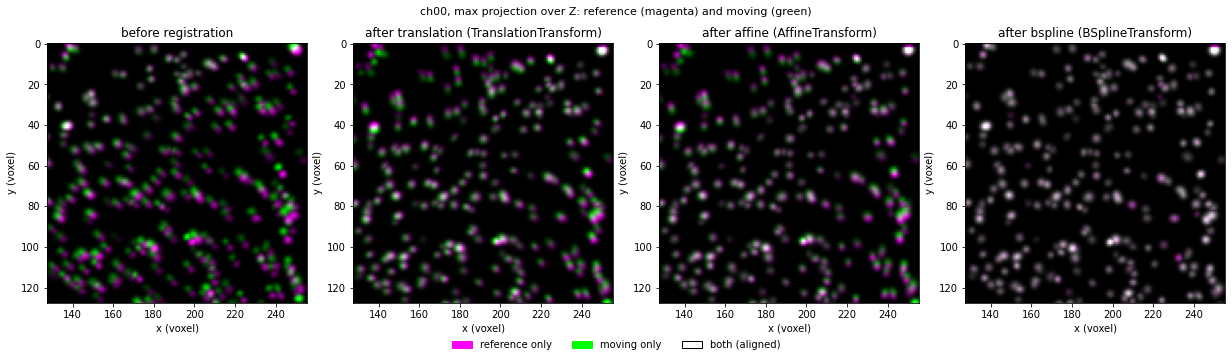

In [17]:
from matplotlib.patches import Patch

half = SHAPE[1] // 2, SHAPE[2] // 2
quadrants = {(y, x): np.linalg.norm(truth[:, y:y + half[0], x:x + half[1]], axis=-1).mean()
             for y in (0, half[0]) for x in (0, half[1])}
y0, x0 = max(quadrants, key=quadrants.get)
window = (slice(y0, y0 + half[0]), slice(x0, x0 + half[1]))


def scaled(signal):
    return np.clip((signal.max(axis=0)[window] - display[0]) / (display[1] - display[0]), 0, 1)


def overlay(moving):
    r, g = scaled(reference_signal), scaled(moving)
    return np.stack([r, g, r], axis=-1)


panels = [("before registration", moving_signal)]
for label in ("translation", "affine", "bspline"):
    result = RESULTS[label]
    after = apply_transform(moving_signal, result.transform, config=replace(result.application_config,
                                                                            output_dtype="float64"))
    panels.append((f"after {label} ({type(result.transform).__name__})", after))

fig, axes = plt.subplots(1, 4, figsize=(17, 4.9), dpi=72, constrained_layout=True)
extent = (x0 - 0.5, x0 + half[1] - 0.5, y0 + half[0] - 0.5, y0 - 0.5)
for axis, (title, signal) in zip(axes, panels):
    axis.imshow(overlay(signal), extent=extent)
    axis.set(title=title, xlabel="x (voxel)", ylabel="y (voxel)")
fig.suptitle("ch00, max projection over Z: reference (magenta) and moving (green)", fontsize=11)
fig.legend(handles=[Patch(color="magenta", label="reference only"), Patch(color="lime", label="moving only"),
                    Patch(facecolor="white", edgecolor="black", label="both (aligned)")],
           loc="outside lower center", ncol=3, frameon=False)
plt.show()

**Small-Z and dimension rules.** The rules come from each method's declared `dimensions`
and `min_shape_zyx`, and are checked before a method runs, so a rejected shape raises
`IncompatibleGeometryError` without touching the backend. Methods with `2` in
`dimensions` estimate Z=1 as 2D (the Z=1 pair above); TPS and CPD are 3D only; and a 3D
estimate needs at least as many planes as the first entry of the method's `min_shape_zyx`,
printed next to each method below. TPS and CPD are declared for Z=2 and Z=3, where their
landmark estimators may still fail on a thin slab.
The table runs every method on the Z=1 pair and on the first two and three planes of the
3D pair; a success reports the largest absolute Z component of the estimated field.

In [18]:
from starfinder.image import IncompatibleGeometryError
from starfinder.registration import RegistrationEstimationError

CONFIGS = {"translation": TranslationConfig(), "rigid": RigidConfig(), "affine": AffineConfig(),
           "bspline": BSplineConfig(), "demons": DemonsConfig(), "tps": TpsConfig(), "cpd": CpdConfig()}
assert list(CONFIGS) == [spec.name for spec in REGISTRATION_METHODS.values()]


def outcome(config, reference, moving, metadata):
    try:
        result = estimate_transform(reference, moving, config=config, reference_metadata=metadata[0],
                                    moving_metadata=metadata[1])
    except (IncompatibleGeometryError, RegistrationEstimationError) as error:
        return f"{type(error).__name__}: {error}"
    u = TransformChain((result.transform,)).pull_field().displacement_zyx
    return f"ok, max |u_z| = {np.abs(u[..., 0]).max():.3f}"


small_z = {}
for name, config in CONFIGS.items():
    small_z[name] = {"Z=1": outcome(config, z1_reference, z1_moving, z1_metadata)}
    for z in (2, 3):
        small_z[name][f"Z={z}"] = outcome(config, reference_signal[:z], moving_signal[:z],
                                          (reference_metadata, moving_metadata))
dimensions = registry.set_index("name")["dimensions"]
for name, outcomes in small_z.items():
    print(f"{name} (declared {dimensions[name]}, min_shape_zyx {REGISTRATION_METHODS[type(CONFIGS[name])].min_shape_zyx})")
    for z, text in outcomes.items():
        print(f"    {z}: {text}")

translation (declared 2D, 3D, min_shape_zyx (1, 1, 1))
    Z=1: ok, max |u_z| = 0.000
    Z=2: ok, max |u_z| = 0.000
    Z=3: ok, max |u_z| = 0.000
rigid (declared 2D, 3D, min_shape_zyx (4, 16, 16))
    Z=1: ok, max |u_z| = 0.000
    Z=2: IncompatibleGeometryError: rigid requires 3D input with every axis at least (4, 16, 16), not (2, 256, 256)
    Z=3: IncompatibleGeometryError: rigid requires 3D input with every axis at least (4, 16, 16), not (3, 256, 256)
affine (declared 2D, 3D, min_shape_zyx (4, 16, 16))
    Z=1: ok, max |u_z| = 0.000
    Z=2: IncompatibleGeometryError: affine requires 3D input with every axis at least (4, 16, 16), not (2, 256, 256)
    Z=3: IncompatibleGeometryError: affine requires 3D input with every axis at least (4, 16, 16), not (3, 256, 256)
bspline (declared 2D, 3D, min_shape_zyx (4, 16, 16))
    Z=1: ok, max |u_z| = 0.000
    Z=2: IncompatibleGeometryError: bspline requires 3D input with every axis at least (4, 16, 16), not (2, 256, 256)
    Z=3: Incompatib

## 4. Recipes and composition

`estimate_transform` estimates one method. The pipeline registers a moving round with a
**recipe**: `RegistrationRecipe(steps, signal, warp, reference_round, qc)` in
`starfinder.dataset`, whose `steps` are `RegistrationStep(config, recovery, signal)`
entries ([docs/registration-contract.md](../../docs/registration-contract.md#registrationrecipe)).
Validation happens when the recipe is built, before any image is read: every config must
be a registered type, and the sequence must be zero or more global steps followed by at
most one local step. `PipelineConfig.registration` takes a recipe or `None`; the earlier
tuple of steps is rejected.

In [19]:
from starfinder.dataset import RegistrationRecipe, RegistrationStep

recipe = RegistrationRecipe((RegistrationStep(TranslationConfig()), RegistrationStep(AffineConfig()),
                             RegistrationStep(BSplineConfig())))
print("accepted:", [REGISTRATION_METHODS[type(step.config)].name for step in recipe.steps])
print("defaults: signal", recipe.signal, "| warp", recipe.warp, "| qc", recipe.qc)
for attempt in (lambda: RegistrationRecipe((RegistrationStep(DemonsConfig()), RegistrationStep(TranslationConfig()))),
                lambda: RegistrationRecipe(()),
                lambda: PipelineConfig(registration=(RegistrationStep(TranslationConfig()),))):
    try:
        attempt()
    except (TypeError, ValueError) as error:
        print(f"rejected: {type(error).__name__}: {error}")

accepted: ['translation', 'affine', 'bspline']
defaults: signal RegistrationSignalConfig(mode='max', reference_channel=None, moving_channel=None) | warp None | qc RegistrationQcConfig(min_coverage=None, min_ncc_gain=None, max_fold_fraction=None, max_translation_voxels=None, projections=False)
rejected: ValueError: registration steps ('demons', 'translation') are not global steps followed by at most one local step
rejected: ValueError: a registration recipe requires at least one step
rejected: TypeError: registration requires its typed operation config


**The registration signal.** `RegistrationSignalConfig` builds one float64 ZYX signal per
round from its ZYXC image: `max` (the default, the channel maximum, as MATLAB's merged
image), `sum` (the float64 channel sum, the earlier Python default) or `channel` (one
channel per round, by index or label, with `moving_channel` for a round whose stain is in
another channel). A step can override the recipe's signal. The next cell shows the
validation, then registers the same pair with a translation recipe under each mode through
`FOV.run`; the helper `pair_fov` puts both four-channel rounds on a fresh two-round FOV
that writes nothing.

In [20]:
from starfinder.dataset import Dataset, RoundState
from starfinder.registration import RegistrationSignalConfig

for kwargs in (dict(mode="channel"), dict(mode="max", reference_channel=0)):
    try:
        RegistrationSignalConfig(**kwargs)
    except ValueError as error:
        print(f"RegistrationSignalConfig({kwargs}) rejected: {error}")

CHANNELS = tuple(scene.channel_labels)


def pair_fov(name="pair"):
    dataset = Dataset(input_root=WORKSPACE / "input", output_root=WORKSPACE / name, dataset_id="tour",
                      sample_id="synthetic", output_id=name,
                      rounds=RoundState(sequencing_rounds=[REFERENCE, MOVING], reference_round=REFERENCE),
                      channel_order=CHANNELS)
    fov = dataset.fov("FOV_001")
    fov.images = {REFERENCE: reference_round, MOVING: moving_round}
    fov.metadata = {REFERENCE: reference_metadata, MOVING: moving_metadata}
    return fov


for signal in (RegistrationSignalConfig(), RegistrationSignalConfig("sum"),
               RegistrationSignalConfig("channel", reference_channel="ch00")):
    fov = pair_fov().run(PipelineConfig(registration=RegistrationRecipe((RegistrationStep(TranslationConfig()),),
                                                                        signal=signal)))
    print(f"{signal}: displacement {fov.registration_results[MOVING][0].transform.displacement_zyx}")

RegistrationSignalConfig({'mode': 'channel'}) rejected: mode="channel" requires reference_channel
RegistrationSignalConfig({'mode': 'max', 'reference_channel': 0}) rejected: channels apply only to mode="channel"


RegistrationSignalConfig(mode='max', reference_channel=None, moving_channel=None): displacement (1.0, -2.0, -1.0)


RegistrationSignalConfig(mode='sum', reference_channel=None, moving_channel=None): displacement (1.0, -2.0, -1.0)


RegistrationSignalConfig(mode='channel', reference_channel='ch00', moving_channel=None): displacement (1.0, -2.0, -1.0)


**Composition.** Step k of a recipe is estimated on the moving signal already resampled
(in float64, without rounding) through steps 1 to k−1, so its transform maps reference
points into that intermediate image. The composite pull map of a round with steps
`T₁ … Tₙ` is therefore `Φ(p) = T₁(T₂(…Tₙ(p)))`: the last step is applied first.
`TransformChain` holds the ordered step transforms, and `pull_field()` returns
`u(p) = Φ(p) − p` as a float64 `DenseDisplacementTransform`, evaluating the last transform
at grid points and every earlier one analytically, so no dense field is ever
interpolated. The next cell runs a (translation, affine) recipe on `ch00`, takes the
round's chain, and checks `pull_field()` against `A p + b + d` evaluated directly from the
stored parameters, and against the wrong order `A (p + d) + b`.

In [21]:
two_step = RegistrationRecipe((RegistrationStep(TranslationConfig()), RegistrationStep(AffineConfig())),
                              signal=RegistrationSignalConfig("channel", reference_channel="ch00"))
chain_fov = pair_fov().run(PipelineConfig(registration=two_step))
chain = chain_fov.registration_chains[MOVING]
translation_step, affine_step = chain.transforms
print("chain:", [type(t).__name__ for t in chain.transforms])
print("step 1 displacement d:", translation_step.displacement_zyx)
print("step 2 [[A, b], [0, 1]]:")
print(np.array2string(affine_step.matrix_zyx, precision=4, suppress_small=True))

u_chain = chain.pull_field().displacement_zyx
points = np.moveaxis(np.indices(SHAPE, dtype=np.float64), 0, -1)
A, b = affine_step.matrix_zyx[:3, :3], affine_step.matrix_zyx[:3, 3]
d = np.asarray(translation_step.displacement_zyx)
expected = points @ A.T + b + d - points
wrong_order = (points + d) @ A.T + b - points
print(f"max |pull_field - (A p + b + d - p)| = {np.abs(u_chain - expected).max():.2e} voxel")
print(f"max |pull_field - wrong order|       = {np.abs(u_chain - wrong_order).max():.3f} voxel")
chain_error = evaluate_displacement_field(u_chain, truth, mask=valid_overlap(u_chain)).values
print("chain error vs truth:", {k: round(v, 3) for k, v in chain_error.items()})

chain: ['TranslationTransform', 'AffineTransform']
step 1 displacement d: (1.0, -2.0, -1.0)
step 2 [[A, b], [0, 1]]:
[[ 0.9191  0.0001 -0.0003  1.1105]
 [ 0.0054  0.9966 -0.0006  0.6171]
 [ 0.0006 -0.0061  0.9953  0.9008]
 [ 0.      0.      0.      1.    ]]
max |pull_field - (A p + b + d - p)| = 5.68e-14 voxel
max |pull_field - wrong order|       = 0.081 voxel


chain error vs truth: {'median_error': 1.342, 'p95_error': 4.871, 'max_error': 8.873}


**One final resampling.** After all steps are estimated, every image of the moving round
(all channels, and every preprocessing snapshot kept for it) is resampled **once**, from
its pre-registration array, at the composite pull points. A chain of translations uses the
exact translation path; any other chain is sampled with linear interpolation, plane by
plane, and integer outputs are rounded to the nearest even integer, clipped and cast once.
The alternative, resampling after every step, changes the result in two ways. At the
boundary, the first pass fills the voxels it shifts in from outside the grid, and the
second pass interpolates across the edge of that fill, so voxels whose composite pull
point leaves the moving grid get values blended from fill and image data instead of the
fill value the boundary policy specifies. And a fractional step would be interpolated and
rounded to the integer dtype between the passes.

The next cell checks that the registered round `FOV.run` produced equals one resampling of
the pre-registration round through the chain, then resamples the same round in two passes
(the translation, then the affine) and compares the two, split by whether a voxel's
composite pull point lies inside the moving grid (the valid overlap) or in the boundary
band outside it.

In [22]:
single = apply_transform(moving_round, chain, config=WarpConfig(backend="scipy"))
print("FOV.run output equals one resampling through the chain:", np.array_equal(single, chain_fov.images[MOVING]))
first_pass = apply_transform(moving_round, translation_step, config=WarpConfig())
two_pass = apply_transform(first_pass, affine_step, config=WarpConfig(backend="scipy"))
print("the translation step is a whole number of voxels, so the first pass is an exact shift:",
      all(float(v).is_integer() for v in translation_step.displacement_zyx))

inside = valid_overlap(u_chain)
difference = np.abs(single.astype(np.int64) - two_pass.astype(np.int64)).max(axis=-1)
print(f"voxels that differ between one and two resamplings: {int((difference > 0).sum())} of {difference.size} "
      f"({(difference > 0).mean():.4f}); largest difference {difference.max()} intensity units")
print(f"  pull point inside the moving grid:  {int(inside.sum())} voxels, "
      f"{int((difference[inside] > 0).sum())} differ")
print(f"  pull point outside (boundary band): {int((~inside).sum())} voxels, "
      f"{int((difference[~inside] > 0).sum())} differ")
print(f"  in the band, one resampling holds the fill value 0 everywhere: {bool(np.all(single[~inside] == 0))}; "
      f"two resamplings hold nonzero blended values in {int((two_pass[~inside].max(axis=-1) > 0).sum())} voxels")

FOV.run output equals one resampling through the chain: True


the translation step is a whole number of voxels, so the first pass is an exact shift: True
voxels that differ between one and two resamplings: 75362 of 1048576 (0.0719); largest difference 3423 intensity units
  pull point inside the moving grid:  967375 voxels, 0 differ
  pull point outside (boundary band): 81201 voxels, 75362 differ
  in the band, one resampling holds the fill value 0 everywhere: True; two resamplings hold nonzero blended values in 75362 voxels


The last panel of the figure counts the differing voxels in each Z plane. The other panels
show the plane with the most of them: at the edge of the stack, the Z component of the
chain moves the pull points of that plane outside the moving grid, so one resampling
gives the fill value there, while two resamplings give values blended from the image's
edge plane and the first pass's fill. The title gives the fraction of the plane's pull
points that stay inside the moving grid.

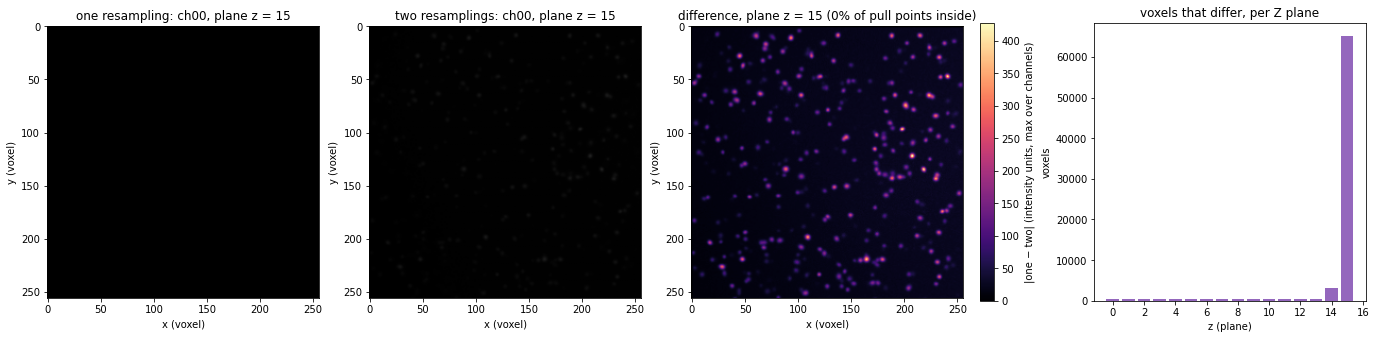

In [23]:
per_plane = (difference > 0).sum(axis=(1, 2))
zb = int(per_plane.argmax())
fig, axes = plt.subplots(1, 4, figsize=(19, 4.6), dpi=72, constrained_layout=True)
for axis, (title, image) in zip(axes, (("one resampling", single), ("two resamplings", two_pass))):
    axis.imshow(image[zb, ..., 0], cmap="gray", vmin=0, vmax=display[1])
    axis.set(title=f"{title}: ch00, plane z = {zb}", xlabel="x (voxel)", ylabel="y (voxel)")
shown = axes[2].imshow(difference[zb], cmap="magma")
fig.colorbar(shown, ax=axes[2], label="|one − two| (intensity units, max over channels)")
axes[2].set(title=f"difference, plane z = {zb} ({inside[zb].mean():.0%} of pull points inside)",
            xlabel="x (voxel)", ylabel="y (voxel)")
axes[3].bar(np.arange(SHAPE[0]), per_plane, color="tab:purple")
axes[3].set(title="voxels that differ, per Z plane", xlabel="z (plane)", ylabel="voxels")
plt.show()

**Boundary modes.** `WarpConfig` is the resampling policy. With `boundary_mode="constant"`
a pull point outside the closed box `[0, n−1]` receives `fill_value` (its default is printed
below);
`nearest` extends the edge values. The translation backend requires constant zero fill,
and applies only chains of translations. The cell resamples `ch00` through the chain above
with both modes and shows the rejected combinations.

In [24]:
from starfinder.registration import InvalidRegistrationConfigError, UnsupportedTransformOperationError

outside = ~inside
print("WarpConfig defaults: boundary_mode", repr(WarpConfig().boundary_mode), " fill_value", WarpConfig().fill_value)
configs = (WarpConfig(backend="scipy", output_dtype="float64"),
           WarpConfig(backend="scipy", fill_value=50, output_dtype="float64"),
           WarpConfig(backend="scipy", boundary_mode="nearest", output_dtype="float64"))
modes = {(f"constant (fill {c.fill_value:g})" if c.boundary_mode == "constant" else c.boundary_mode): c
         for c in configs}
print(f"voxels whose pull point is outside the moving grid: {int(outside.sum())} ({outside.mean():.4f})")
for name, config in modes.items():
    values = np.unique(apply_transform(moving_signal, chain, config=config)[outside])
    shown = values.tolist() if len(values) <= 3 else f"{len(values)} distinct values, min {values.min():.1f}"
    print(f"  {name:<18} values there: {shown}")
for attempt in (lambda: WarpConfig(boundary_mode="nearest"),
                lambda: apply_transform(moving_signal, chain, config=WarpConfig())):
    try:
        attempt()
    except (InvalidRegistrationConfigError, UnsupportedTransformOperationError) as error:
        print(f"rejected: {type(error).__name__}: {error}")

WarpConfig defaults: boundary_mode 'constant'  fill_value 0
voxels whose pull point is outside the moving grid: 81201 (0.0774)
  constant (fill 0)  values there: [0.0]
  constant (fill 50) values there: [50.0]


  nearest            values there: 81193 distinct values, min 94.9
rejected: InvalidRegistrationConfigError: translation requires constant zero fill
rejected: UnsupportedTransformOperationError: the translation backend applies only chains of translations


## 5. QC, rejection and recovery

`registration_qc(reference, before, after, transform, *, config, diagnostics)` in
`starfinder.evaluation.registration` is the routine QC of one step or chain, computed from
the signals alone ([docs/registration-contract.md](../../docs/registration-contract.md#routine-qc)):

* **coverage**, the valid-overlap fraction;
* **NCC** before and after (Pearson correlation over the valid overlap, the same voxels for
  both) and their gain;
* **SSIM** before and after on the Z maximum projections, with a uniform square window over
  the valid columns eroded by a fixed width (the result's `config` records both as
  `ssim_window` and `ssim_erosion`, and the next cell prints them);
* a **transform summary** (for a field: displacement statistics and the fraction of voxels
  where the Jacobian determinant is not positive, that is, folds) and the **optimizer
  diagnostics**;
* and, with `RegistrationQcConfig(projections=True)`, the three projections for overlays.

Every undefined value is `None` with a reason. `FOV` runs it for every successful step and
for each round's whole chain. The next cell runs it on the B-spline estimate of section 3
and checks that its coverage equals the valid-overlap fraction used for the error table.

In [25]:
from starfinder.evaluation.registration import registration_qc
from starfinder.registration import RegistrationQcConfig

after = apply_transform(moving_signal, bspline.transform, config=WarpConfig(backend="scipy", output_dtype="float64"))
qc = registration_qc(reference_signal, moving_signal, after, bspline.transform,
                     config=RegistrationQcConfig(projections=True), diagnostics=bspline.diagnostics)
print("values:", {k: None if v is None else round(v, 4) for k, v in qc.values.items()})
print("counts:", qc.counts)
print("reasons:", qc.reasons)
print("config:", {k: v for k, v in qc.config.items() if k != "qc"})
summary = qc.details["transform"]
print("transform summary:", {k: ({kk: round(vv, 3) for kk, vv in v.items()} if isinstance(v, dict) else v)
                             for k, v in summary.items()})
print("optimizer:", {k: v for k, v in qc.details["optimizer"].items()
                     if k in ("method", "backend", "converged", "iterations_completed", "stop_condition")})
print("projections:", {k: v.shape for k, v in qc.details["projections"].items()})
u_bspline = TransformChain((bspline.transform,)).pull_field().displacement_zyx
print("coverage equals the valid overlap of section 3:", qc.values["coverage"] == valid_overlap(u_bspline).mean())

values: {'coverage': 0.8616, 'ncc_before': 0.3576, 'ncc_after': 0.9919, 'ncc_gain': 0.6343, 'ssim_before': None, 'ssim_after': None}
counts: {'total': 1048576, 'valid': 903457, 'valid_columns': 0, 'ssim_columns': 0}
reasons: {'ssim_before': 'the eroded valid columns are empty', 'ssim_after': 'the eroded valid columns are empty'}
config: {'overlap': 'pull point inside the closed box [0, n-1] on every axis', 'ssim_policy': 'mip', 'ssim_window': 7, 'ssim_erosion': 3, 'data_range': None}
transform summary: {'kind': 'bspline', 'displacement_voxels': {'median': 3.036, 'p95': 4.542, 'max': 5.065}, 'displacement_physical': None, 'fold_fraction': 0.0}
optimizer: {'method': 'bspline', 'backend': 'elastix', 'converged': None, 'iterations_completed': (200, 200, 200, 200), 'stop_condition': ('Maximum number of iterations has been reached.', 'Maximum number of iterations has been reached.', 'Maximum number of iterations has been reached.', 'Maximum number of iterations has been reached.')}
projectio

coverage equals the valid overlap of section 3: True


Here SSIM is undefined, with its reason: the scene's Z translation moves the pull points of
the top or bottom planes outside the moving grid, so no YX column is valid in every plane
(`valid_columns` is 0) and the Z projection has no valid domain. On the Z=1 pair of
section 3 every column is a single plane, and the SSIM of the demons estimate is defined.

In [26]:
z1_after = apply_transform(z1_moving, demons_z1.transform, config=WarpConfig(backend="scipy", output_dtype="float64"))
z1_qc = registration_qc(z1_reference, z1_moving, z1_after, demons_z1.transform, diagnostics=demons_z1.diagnostics)
print("values:", {k: None if v is None else round(v, 4) for k, v in z1_qc.values.items()})
print("counts:", z1_qc.counts, " reasons:", z1_qc.reasons)
print("transform summary:", {k: ({kk: round(vv, 3) for kk, vv in v.items()} if isinstance(v, dict) else v)
                             for k, v in z1_qc.details["transform"].items()})

values: {'coverage': 0.9839, 'ncc_before': 0.4812, 'ncc_after': 0.9986, 'ncc_gain': 0.5174, 'ssim_before': 0.4876, 'ssim_after': 0.9971}
counts: {'total': 65536, 'valid': 64482, 'valid_columns': 64482, 'ssim_columns': 61213}  reasons: {}
transform summary: {'kind': 'dense', 'displacement_voxels': {'median': 2.585, 'p95': 4.359, 'max': 8.06}, 'displacement_physical': None, 'fold_fraction': 0.000213623046875}


**Undefined results.** QC never invents a value. A constant signal has no correlation, a
grid smaller than the SSIM window has no SSIM, and a moving round whose content lies
entirely beyond the grid has no valid overlap at all. Each case returns `None` with the
reason.

In [27]:
def translation(displacement, shape):
    return TranslationTransform(displacement, shape, shape, reference_metadata, moving_metadata)


cases = {
    "constant moving signal": (reference_signal, np.full(SHAPE, 7.0), translation((0, 0, 0), SHAPE)),
    "grid smaller than the window (1x6x6)": (reference_signal[:1, :6, :6], moving_signal[:1, :6, :6],
                                             translation((0, 0, 0), (1, 6, 6))),
    "content beyond the grid": (reference_signal, np.zeros(SHAPE), translation((0, 2 * SHAPE[1], 0), SHAPE)),
}
for name, (reference, moving, transform) in cases.items():
    result = registration_qc(reference, moving, moving, transform)
    print(f"{name}: coverage {result.values['coverage']:.3f}")
    for key, reason in result.reasons.items():
        print(f"    {key:<11} None: {reason}")

constant moving signal: coverage 1.000
    ncc_before  None: constant signal over the valid overlap
    ncc_after   None: constant signal over the valid overlap
    ncc_gain    None: ncc_before or ncc_after is undefined
grid smaller than the window (1x6x6): coverage 1.000
    ssim_before None: Y or X is smaller than the 7x7 window
    ssim_after  None: Y or X is smaller than the 7x7 window
content beyond the grid: coverage 0.000
    ncc_before  None: no valid overlap
    ncc_after   None: no valid overlap
    ncc_gain    None: ncc_before or ncc_after is undefined
    ssim_before None: the eroded valid columns are empty
    ssim_after  None: the eroded valid columns are empty


**Rejection.** `RegistrationQcConfig` holds optional rejection criteria: `min_coverage`,
`min_ncc_gain`, `max_fold_fraction` and `max_translation_voxels`. All are `None` by
default, so nothing is rejected unless a recipe sets one. A step that fails a configured
criterion raises `RegistrationRejectedError` (a `RegistrationEstimationError`) naming the
criterion, the value and the bound, and its attempt record says `rejected`.

**Recovery.** A `RegistrationStep` may carry a `RecoveryConfig`: the error categories it
allows and ordered alternative configs of the same step kind. Only estimation errors can
be recovered (validation, geometry, dependency and application errors never are), and
every attempt is recorded. The next cell first runs a translation recipe whose QC bounds
the translation norm (the QC config `bounded`, printed by the cell), which rejects it; then the same recipe with rigid as the
recovery alternative (the translation criterion applies only to translations).

In [28]:
from starfinder.dataset import RecoveryConfig
from starfinder.registration import RegistrationRejectedError

bounded = RegistrationQcConfig(max_translation_voxels=1.0)
print("bounded:", bounded)
channel0 = RegistrationSignalConfig("channel", reference_channel="ch00")
rejecting = pair_fov()
try:
    rejecting.run(PipelineConfig(registration=RegistrationRecipe((RegistrationStep(TranslationConfig()),),
                                                                 signal=channel0, qc=bounded)))
except RegistrationRejectedError as error:
    print(f"{type(error).__name__}: {error}")
print("attempt:", {k: rejecting.registration_attempts[MOVING][0][k] for k in ("record", "outcome", "failure")})

recovering = pair_fov().run(PipelineConfig(registration=RegistrationRecipe(
    (RegistrationStep(TranslationConfig(), recovery=RecoveryConfig((RegistrationEstimationError,), (RigidConfig(),))),),
    signal=channel0, qc=bounded)))
columns = ["record", "step", "attempt", "requested_method", "actual_method", "fallback", "backend", "outcome"]


def cell(entry, key):
    value = entry.get(key)
    if key == "failure" and value is not None:
        return f"{value['type']} ({value.get('criterion')})"
    return "" if value is None else value


attempts = pd.DataFrame([{key: cell(entry, key) for key in columns + ["failure"]}
                         for entry in recovering.registration_attempts[MOVING]])
print()
print(attempts.to_string(index=False))
print("\nbackend versions of the recovered attempt:", recovering.registration_attempts[MOVING][1]["backend_versions"])
print("application:", recovering.registration_attempts[MOVING][2]["application_config"])

[FOV_001] Failed register: max_translation_voxels: 2.449489742783178 is above the bound 1.0


[FOV_001] Failed run: max_translation_voxels: 2.449489742783178 is above the bound 1.0


bounded: RegistrationQcConfig(min_coverage=None, min_ncc_gain=None, max_fold_fraction=None, max_translation_voxels=1.0, projections=False)
RegistrationRejectedError: max_translation_voxels: 2.449489742783178 is above the bound 1.0
attempt: {'record': 'estimation', 'outcome': 'rejected', 'failure': {'type': 'RegistrationRejectedError', 'message': 'max_translation_voxels: 2.449489742783178 is above the bound 1.0', 'criterion': 'max_translation_voxels'}}



     record step attempt requested_method actual_method fallback   backend   outcome                                            failure
 estimation    0       0      translation   translation    False scipy_fft  rejected RegistrationRejectedError (max_translation_voxels)
 estimation    0       1      translation         rigid     True   elastix succeeded                                                   
application                                                                succeeded                                                   

backend versions of the recovered attempt: {'itk-elastix': '0.25.4', 'itk': '5.4.7'}
application: {'backend': 'scipy', 'boundary_mode': 'constant', 'fill_value': 0, 'output_dtype': 'input', 'integer_rounding': 'nearest_even', 'clip_to_dtype': True, 'fft_workers': 1}


## 6. One field of view through `FOV.run`

In the pipeline a recipe is one stage of `PipelineConfig`. `FOV.run` validates the whole
configuration first, then registers every moving round: it builds the signals, estimates
each step (with QC and any recovery), composes the chain, resamples the round once and
records everything. The FOV keeps, per moving round:

* `registration_results`: the ordered step results, each with the round's single
  application policy;
* `registration_chains`: the `TransformChain`;
* `registration_attempts`: one estimation entry per attempt and one application entry;
* and `registration_record`: the recipe summary and the application policy per round.

With a `CheckpointConfig`, `run` also writes the `registered` checkpoint (in its current
format, whose `format_version` the second cell below prints) and
the run record `run.json` ([docs/checkpoints.md](../../docs/checkpoints.md)). The next cell
runs a (translation, B-spline) recipe on `ch00` of the pair with that checkpoint.

In [29]:
from starfinder.dataset import CheckpointConfig

pipeline = PipelineConfig(registration=RegistrationRecipe(
    (RegistrationStep(TranslationConfig()), RegistrationStep(BSplineConfig())), signal=channel0))
fov = pair_fov("pipeline")
fov.run(pipeline, checkpoints=CheckpointConfig(stages=("registered",)))
show(fov)
for result in fov.registration_results[MOVING]:
    print(result, "| application:", result.application_config.backend)
print("record:", {k: v for k, v in fov.registration_record.items() if k != "recipe"})
print("recipe:", fov.registration_record["recipe"]["steps"], fov.registration_record["recipe"]["signal"])
print("attempts:", [(a["record"], a.get("actual_method"), a["outcome"]) for a in fov.registration_attempts[MOVING]])
u_fov = fov.registration_chains[MOVING].pull_field().displacement_zyx
print("chain error vs truth:",
      {k: round(v, 3) for k, v in evaluate_displacement_field(u_fov, truth, mask=valid_overlap(u_fov)).values.items()})

FOV 'FOV_001' of Dataset 'tour' (sample 'synthetic')
    images:   reference*, polynomial_small — (16, 256, 256, 4) uint16 ZYXC   (* reference)
    channels: ch00, ch01, ch02, ch03
    results:  registration
      registration  1 moving round, translation, bspline
RegistrationResult: translation (scipy_fft), displacement_zyx (1, -2, -1) | application: scipy
RegistrationResult: bspline (elastix), B-spline grid (11, 11, 4) (XYZ) | application: scipy
record: {'semantics': 'recipe', 'application': {'polynomial_small': WarpConfig(backend='scipy', boundary_mode='constant', fill_value=0, output_dtype='input', integer_rounding='nearest_even', clip_to_dtype=True, fft_workers=1)}}
recipe: ['translation', 'bspline'] {'mode': 'channel', 'reference_channel': 'ch00', 'moving_channel': None}
attempts: [('estimation', 'translation', 'succeeded'), ('estimation', 'bspline', 'succeeded'), ('application', None, 'succeeded')]
chain error vs truth: {'median_error': 0.343, 'p95_error': 0.816, 'max_error': 2.

**The checkpoint and the run record.** `registered/` holds each round as a ZYXC OME-TIFF,
`transforms.json` with the transforms (inline for translation and affine, with the
B-spline coefficients and dense fields in `<round>_field.npz`), the per-round application
policy and the recipe. `run.json` records the configuration, including the recipe's
fields, and under `registration` the same attempt records as the FOV.

In [30]:
checkpoint_dir = fov.paths.checkpoint_dir
for path in sorted(checkpoint_dir.rglob("*")):
    if path.is_file():
        print(rel(path))

header = json.loads((checkpoint_dir / "registered" / "transforms.json").read_text())
print("\ntransforms.json format_version:", header["format_version"], " keys:", sorted(header))
run_record = json.loads((checkpoint_dir / "run.json").read_text())
print("run.json status:", run_record["status"], " registration rounds:", list(run_record["registration"]))
print("run.json registration entries of the moving round:")
for entry in run_record["registration"][MOVING]:
    print("   ", {k: entry[k] for k in ("record", "step", "actual_method", "backend", "outcome") if k in entry})
print("run.json config.pipeline.registration keys:", sorted(run_record["config"]["pipeline"]["registration"]))

pipeline/checkpoints/FOV_001/registered/polynomial_small.ome.tif
pipeline/checkpoints/FOV_001/registered/polynomial_small_field.npz
pipeline/checkpoints/FOV_001/registered/reference.ome.tif
pipeline/checkpoints/FOV_001/registered/transforms.json
pipeline/checkpoints/FOV_001/run.json

transforms.json format_version: 2  keys: ['applications', 'channel_labels', 'dataset_id', 'format_version', 'fov_id', 'image_rounds', 'preprocessing', 'registration_attempts', 'registration_recipe', 'registration_semantics', 'rounds', 'sample_id', 'snapshots', 'stage', 'subtile_id', 'transforms']
run.json status: succeeded  registration rounds: ['polynomial_small']
run.json registration entries of the moving round:
    {'record': 'estimation', 'step': 0, 'actual_method': 'translation', 'backend': 'scipy_fft', 'outcome': 'succeeded'}
    {'record': 'estimation', 'step': 1, 'actual_method': 'bspline', 'backend': 'elastix', 'outcome': 'succeeded'}
    {'record': 'application', 'outcome': 'succeeded'}
run.json

**Reload and re-apply.** A fresh FOV from the same dataset restores the `registered`
stage: images, results, attempts, chains and the application policy. Because JSON floats
round-trip exactly and the arrays are stored as float64, the reloaded chain's pull field
is bit-identical to the one of the run, and applying the reloaded chain with the stored
policy to the pre-registration round reproduces the registered round exactly.

In [31]:
reloaded = fov.dataset.fov("FOV_001").load_checkpoint("registered")
reloaded_chain = reloaded.registration_chains[MOVING]
warp = reloaded.registration_record["application"][MOVING]
print("reloaded chain:", [type(t).__name__ for t in reloaded_chain.transforms], " policy:", warp)
print("pull field bit-identical:", np.array_equal(reloaded_chain.pull_field().displacement_zyx,
                                                  fov.registration_chains[MOVING].pull_field().displacement_zyx))
print("re-applied round bit-identical to the run:",
      np.array_equal(apply_transform(moving_round, reloaded_chain, config=warp), fov.images[MOVING]))
print("reloaded images bit-identical:",
      all(np.array_equal(reloaded.images[name], fov.images[name]) for name in (REFERENCE, MOVING)))

reloaded chain: ['TranslationTransform', 'BSplineTransform']  policy: WarpConfig(backend='scipy', boundary_mode='constant', fill_value=0, output_dtype='input', integer_rounding='nearest_even', clip_to_dtype=True, fft_workers=1)


pull field bit-identical: True


re-applied round bit-identical to the run: True
reloaded images bit-identical: True


**The workflow key.** Snakemake runs read a shared YAML configuration
([docs/workflow-configuration.md](../../docs/workflow-configuration.md)). A Python rule may
declare a recipe explicitly with the Python-only `registration` key, whose steps name
registered methods and give their config fields. Otherwise the shared MATLAB blocks
`global_registration` and `local_registration` map to one recipe (the legacy mapping):
one global step, then one local step, with `merged-image` meaning the channel maximum. The
two forms are mutually exclusive. The cell starts from the repository's minimal workflow
example and prints each form as YAML with the recipe the adapter builds.

In [32]:
import copy

import yaml

from starfinder.dataset import from_workflow_config

base = yaml.safe_load((REPOSITORY / "docs" / "examples" / "workflow-minimal.yaml").read_text())


def adapt(parameters):
    config = copy.deepcopy(base)
    rule = config["rules"]["rsf_single_fov"]["parameters"]
    rule.pop("global_registration")
    rule.update(parameters)
    return from_workflow_config(config).pipeline.registration


def describe(recipe):
    steps = []
    for step in recipe.steps:
        text = REGISTRATION_METHODS[type(step.config)].name
        if step.recovery:
            text += " (recovery: " + ", ".join(c.method for c in step.recovery.alternatives) + ")"
        steps.append(text)
    return f"steps {steps}\n   signal {recipe.signal}\n   warp {recipe.warp}\n   qc {recipe.qc}"


explicit = yaml.safe_load('''
registration:
  signal: {mode: channel, reference_channel: ch00}
  warp: {backend: scipy, boundary_mode: nearest}
  qc: {min_coverage: 0.5}
  steps:
    - method: translation
    - method: affine
      iterations: 100
    - method: bspline
      recovery: {allowed_errors: [RegistrationEstimationError], alternatives: [{method: demons}]}
''')
legacy = yaml.safe_load('''
global_registration: {run: true, method: translation, ref_img: merged-image, mov_img: merged-image}
local_registration: {run: true, method: demons, iterations: [50, 25]}
''')
for title, parameters in (("Python-only registration key", explicit), ("legacy mapping", legacy)):
    print(f"# {title}")
    print(yaml.safe_dump(parameters, sort_keys=False, default_flow_style=None).rstrip())
    print("->", describe(adapt(parameters)), "\n")
try:
    adapt({**explicit, **legacy})
except ValueError as error:
    print("both forms together:", error)

# Python-only registration key
registration:
  signal: {mode: channel, reference_channel: ch00}
  warp: {backend: scipy, boundary_mode: nearest}
  qc: {min_coverage: 0.5}
  steps:
  - {method: translation}
  - {method: affine, iterations: 100}
  - method: bspline
    recovery:
      allowed_errors: [RegistrationEstimationError]
      alternatives:
      - {method: demons}
-> steps ['translation', 'affine', 'bspline (recovery: demons)']
   signal RegistrationSignalConfig(mode='channel', reference_channel='ch00', moving_channel=None)
   warp WarpConfig(backend='scipy', boundary_mode='nearest', fill_value=0, output_dtype='input', integer_rounding='nearest_even', clip_to_dtype=True, fft_workers=1)
   qc RegistrationQcConfig(min_coverage=0.5, min_ncc_gain=None, max_fold_fraction=None, max_translation_voxels=None, projections=False) 

# legacy mapping
global_registration: {run: true, method: translation, ref_img: merged-image, mov_img: merged-image}
local_registration:
  run: true
  method: 

## 7. Other-round and external-reference registration

Some rounds are not sequencing rounds, for example a morphology round, and share only one
stain with the reference round. `FOV.register_rounds(recipe, *, rounds, reference=None)`
registers them natively in Python: the recipe's signal is `mode="channel"`, naming the
shared stain in the reference round (`reference_channel`) and in each other round
(`moving_channel`, by the round's own channel labels from `Dataset.other_channel_order`).
The chain is estimated on the stain alone and then transferred: every channel of the round
(and every snapshot kept for it) is resampled once through it
([docs/registration-contract.md](../../docs/registration-contract.md#other-round-and-external-reference-registration)).

Here the deformed round of the pair plays an other round called `morphology`, with its
own labels: its `ch00` becomes the shared `stain`, and two further channels are carried
along. Label and grid errors are raised before any estimator runs.

In [33]:
OTHER = "morphology"
OTHER_LABELS = ("stain", "ch01", "ch02")
other_round = np.ascontiguousarray(moving_round[..., :3])


def other_round_fov(name):
    dataset = Dataset(input_root=WORKSPACE / "input", output_root=WORKSPACE / name, dataset_id="tour",
                      sample_id="synthetic", output_id=name,
                      rounds=RoundState(sequencing_rounds=[REFERENCE], other_rounds=[OTHER], reference_round=REFERENCE),
                      channel_order=CHANNELS, other_channel_order={OTHER: OTHER_LABELS})
    fov = dataset.fov("FOV_001")
    fov.images = {REFERENCE: reference_round, OTHER: other_round}
    fov.metadata = {REFERENCE: reference_metadata, OTHER: moving_metadata}
    return fov


stain = RegistrationRecipe((RegistrationStep(TranslationConfig()), RegistrationStep(BSplineConfig())),
                           signal=RegistrationSignalConfig("channel", reference_channel="ch00", moving_channel="stain"))
try:
    other_round_fov("other").register_rounds(replace(stain, signal=RegistrationSignalConfig(
        "channel", reference_channel="ch00", moving_channel="dapi")), rounds=[OTHER])
except ValueError as error:
    print("rejected before estimation:", error)

other = other_round_fov("other").register_rounds(stain, rounds=[OTHER])
print("labels of", OTHER, other.dataset.channel_labels(OTHER))
round_record = other.registration_record["rounds"][OTHER]
print("record:", {"steps": round_record["recipe"]["steps"], "signal": round_record["recipe"]["signal"],
                  "reference": round_record["reference"], "reference_sha256": round_record["reference_sha256"]})
print("attempts:", [(a["record"], a.get("actual_method"), a.get("reference"), a["outcome"])
                    for a in other.registration_attempts[OTHER]])
other_chain = other.registration_chains[OTHER]
u_other = other_chain.pull_field().displacement_zyx
print("chain error vs truth:",
      {k: round(v, 3) for k, v in evaluate_displacement_field(u_other, truth, mask=valid_overlap(u_other)).values.items()})

[FOV_001] Failed register_rounds: registration channel 'dapi' is not a channel label of round 'morphology'


rejected before estimation: registration channel 'dapi' is not a channel label of round 'morphology'


labels of morphology ('stain', 'ch01', 'ch02')
record: {'steps': ['translation', 'bspline'], 'signal': {'mode': 'channel', 'reference_channel': 'ch00', 'moving_channel': 'stain'}, 'reference': 'reference', 'reference_sha256': None}
attempts: [('estimation', 'translation', 'reference', 'succeeded'), ('estimation', 'bspline', 'reference', 'succeeded'), ('application', None, None, 'succeeded')]
chain error vs truth: {'median_error': 0.343, 'p95_error': 0.816, 'max_error': 2.532}


**Transfer to the other channels.** Each channel of the registered round equals that
channel resampled once through the chain estimated on the stain. Because the channels of
this synthetic round share the deformation, the non-stain channels also align with the
reference round's channels of the same label: their correlation with the reference rises
after registration.

In [34]:
registered_other = other.images[OTHER]
policy = other.registration_record["application"][OTHER]
inside_other = valid_overlap(u_other)
for c, label in enumerate(OTHER_LABELS):
    same = np.array_equal(registered_other[..., c], apply_transform(other_round[..., c], other_chain, config=policy))
    reference_channel = reference_round[..., CHANNELS.index("ch00" if label == "stain" else label)]
    before, after = (np.corrcoef(reference_channel[inside_other].astype(float), image[inside_other].astype(float))[0, 1]
                     for image in (other_round[..., c], registered_other[..., c]))
    print(f"{label:<6} resampled once through the stain chain: {same};  "
          f"correlation with the reference channel over the valid overlap: before {before:.3f}, after {after:.3f}")

stain  resampled once through the stain chain: True;  correlation with the reference channel over the valid overlap: before 0.360, after 0.978
ch01   resampled once through the stain chain: True;  correlation with the reference channel over the valid overlap: before 0.408, after 0.691
ch02   resampled once through the stain chain: True;  correlation with the reference channel over the valid overlap: before 0.434, after 0.558


**External reference.** An `ExternalReference(image, metadata, label)` supplies the
reference signal directly, for a stain that is not a round of the dataset. It must be on
the grid of the rounds it registers, and every attempt records its label and the SHA-256
of its bytes. Here the external image is the reference round's `ch00`, so the result must
be identical to registering against the reference round.

In [35]:
import hashlib

from starfinder.dataset import ExternalReference

external = ExternalReference(image=np.ascontiguousarray(reference_round[..., 0]), metadata=reference_metadata,
                             label="reference:ch00")
by_external = other_round_fov("external").register_rounds(stain, rounds=[OTHER], reference=external)
attempt = by_external.registration_attempts[OTHER][0]
digest = hashlib.sha256(external.image.tobytes()).hexdigest()
print("attempt reference:", attempt["reference"], " sha256 recorded:", attempt["reference_sha256"][:16] + "...",
      " matches the image:", attempt["reference_sha256"] == digest)
print("chain identical to the round-reference chain:",
      np.array_equal(by_external.registration_chains[OTHER].pull_field().displacement_zyx, u_other))
print("registered round identical:", np.array_equal(by_external.images[OTHER], registered_other))

attempt reference: reference:ch00  sha256 recorded: 04bc864ae3761ca0...  matches the image: True
chain identical to the round-reference chain: True
registered round identical: True


## 8. How it is checked, and known limits

The registration module is checked in layers, all on synthetic or small inputs; none of
them validates accuracy on real tissue ([docs/contributing.md](../../docs/contributing.md)).

* **Unit and contract tests** (`test/test_registration*.py`) cover the configs, the
  registry, each method, the transform types, composition, resampling, QC, recipes, the
  workflow key and other-round registration.
* **The golden test** (`test/test_registration_golden.py`) pins, with exact SHA-256
  digests, the registered images and transforms of a translation-only run and a
  translation → demons run through `FOV.run` on one seeded fixture, so any behavior change
  (a changed default, signal mode or resampling) changes a digest and must be reviewed.
* **The engineering validation** (`test/test_registration_validation.py`, checks V1 to V11
  of [docs/registration-algorithms.md](../../docs/registration-algorithms.md#engineering-validation-design-task-group-6))
  runs known-answer synthetic scenes against tolerances fixed before the run. They are
  engineering bounds that detect a broken implementation, not accuracy claims:

| Check | What it checks |
| --- | --- |
| V1 | A known translation is recovered exactly, per axis, through `estimate_transform` and the registration benchmark task. |
| V2, V3 | Known rigid and affine maps are recovered through (translation, rigid) and (translation, affine) recipes in `FOV.run`, including Z=1 and anisotropic spacing. |
| V4, V5 | Known smooth deformations are recovered by (translation, B-spline) in 3D and on Z=1, and by (translation, demons) on Z=1, better than doing nothing, with no Z motion on Z=1. |
| V6 | Composition: the analytic examples of the contract, and a (translation, affine, dense) chain against step-by-step evaluation. |
| V7 | Persistence: every transform kind survives a registered checkpoint of the current format bit for bit, and a checkpoint of the first format loads as sequential. |
| V8 | The Z=1 and small-Z rules of every registered method. |
| V9 | Boundary and coverage: constant and nearest fill bands and the exact coverage. |
| V10 | Empty and constant inputs: the typed error, and undefined QC values with reasons. |
| V11 | Determinism: the V2 to V5 recipes give bit-identical transforms and images when run twice at one thread. |

The cell reads the tolerances, the test functions of each check and their tier from the
test modules themselves (it runs no tests).

In [36]:
import ast
import re
import tomllib

tests = REPOSITORY / "src" / "python" / "test"


def module(name):
    return ast.parse((tests / name).read_text())


def constants(tree, names):
    return {node.targets[0].id: ast.literal_eval(node.value) for node in tree.body
            if isinstance(node, ast.Assign) and isinstance(node.targets[0], ast.Name) and node.targets[0].id in names}


validation = module("test_registration_validation.py")
print("tolerances:", constants(validation, {"TRANSLATION_TOLERANCE", "GLOBAL_BOUNDS", "LOCAL_BOUNDS", "EXACT", "SEEDS"}))
checks = {}
for node in validation.body:
    if isinstance(node, ast.FunctionDef) and node.name.startswith("test_v"):
        extended = any("extended" in ast.unparse(d) for d in node.decorator_list)
        label = ", ".join(part.upper() for part in re.findall(r"_(v\d+)(?=_)", node.name.split("_known")[0] + "_"))
        checks.setdefault(label, []).append(node.name + (" [extended]" if extended else ""))
for check, names in sorted(checks.items(), key=lambda item: int(item[0].split(",")[0][1:])):
    print(f"  {check:<7}", ", ".join(names))

golden = module("test_registration_golden.py")
print("\ngolden test functions:", [n.name for n in golden.body if isinstance(n, ast.FunctionDef) and n.name.startswith("test_")])
pinned = next(node.value for node in golden.body if isinstance(node, ast.Assign)
              and isinstance(node.targets[0], ast.Name) and node.targets[0].id == "PINNED_RUNS")
print("golden pinned runs:", [list(ast.literal_eval(key)) for key in pinned.keys])
modules = sorted(tests.glob("test_registration*.py"))
print(f"\nregistration test modules: {len(modules)}, test functions: "
      f"{sum(1 for m in modules for n in ast.walk(ast.parse(m.read_text())) if isinstance(n, ast.FunctionDef) and n.name.startswith('test_'))}")

tolerances: {'SEEDS': (100, 101, 102), 'TRANSLATION_TOLERANCE': 0.5, 'GLOBAL_BOUNDS': (0.25, 0.5), 'LOCAL_BOUNDS': (0.5, 1.0), 'EXACT': 1e-12}
  V1      test_v1_known_translation, test_v1_known_translation_benchmark_task
  V2, V3  test_v2_v3_known_rigid_and_affine_maps_through_recipes
  V4, V5  test_v4_v5_known_deformations_through_recipes [extended]
  V6      test_v6_analytic_composition_examples, test_v6_example_4_physical_to_index_matrix, test_v6_translation_affine_dense_chain_equals_sequential_evaluation
  V7      test_v7_version_2_registered_checkpoint_round_trip, test_v7_version_1_checkpoint_loads_as_sequential
  V8      test_v8_covers_every_registered_method, test_v8_z1_and_small_z_rules
  V9      test_v9_constant_boundary_of_a_translation_only_chain, test_v9_nearest_boundary_of_an_affine_chain
  V10     test_v10_constant_moving_signal_is_rejected, test_v10_constant_signal_qc_is_undefined_with_a_reason, test_v10_moving_round_beyond_the_grid
  V11     test_v11_global_recipes_are_

**The elastix optional extra.** Rigid, affine and B-spline need the `registration-elastix`
extra (`itk-elastix` with `itk`); B-spline and demons also need SimpleITK, from the
`local-registration` extra. Without them, those methods raise
`RegistrationBackendUnavailableError` naming the extra, and every other method keeps
working. elastix is heavy to import, which is why it is imported lazily, only when an
elastix method runs (the setup cell showed that importing the registration module does
not import it). The cell reads the extras from the project file, the installed versions,
and the import cost measured when the backend was chosen, as documented in the
algorithm page.

In [37]:
project = tomllib.loads((REPOSITORY / "src" / "python" / "pyproject.toml").read_text())
extras = project["project"]["optional-dependencies"]
for extra in ("registration-elastix", "local-registration"):
    print(f"{extra}: {extras[extra]}")
print("installed:", {name: installed(name) for name in ("itk-elastix", "itk", "SimpleITK")})
text = (REPOSITORY / "docs" / "registration-algorithms.md").read_text()
cost = re.search(r"measured about (\d+) s of import time and ([\d.]+ to [\d.]+) GB of extra baseline\s+RSS", text)
print(f"documented import cost: about {cost.group(1)} s of import time and {cost.group(2)} GB of extra "
      "baseline memory per process")

registration-elastix: ['itk-elastix==0.25.4', 'itk==5.4.7']
local-registration: ['SimpleITK>=2.3']
installed: {'itk-elastix': '0.25.4', 'itk': '5.4.7', 'SimpleITK': '2.5.3'}
documented import cost: about 11 s of import time and 0.5 to 0.8 GB of extra baseline memory per process


**Known limits.** These are recorded and deliberately left as they are:

* **Translation misses by one voxel in two V1 cases.** On two of the benchmark-appearance
  V1 fixtures the unchanged translation estimator returns a displacement one voxel off on
  one axis. Both are strict expected failures: the bound is not loosened, the gate is
  still computed, and a case that starts passing fails the run. The cause is under
  investigation. The cell below prints the two cases from the test module.
* **V4 and V5 depend on the fixture density.** The smooth-deformation checks pass at the
  chosen amplicon density and exceed their provisional bounds at the sparser development
  density, so the density decides pass or fail; the densities are printed below.
* **TPS and CPD at Z=2 and Z=3.** Both declare 3D support with a small minimum number of
  planes (their `min_shape_zyx`, printed in section 3), so a thin slab is accepted on
  geometry, but their landmark estimators may still fail there; section 3's small-Z table
  shows what they do on this scene.
* **The backend choice is provisional.** elastix for rigid, affine and B-spline and
  SimpleITK for demons were chosen from a development comparison. The detailed comparison
  of methods and backends, and any recommended default, belong to the benchmark stage;
  nothing in this notebook compares them.

In [38]:
misses = constants(validation, {"KNOWN_MISSES"})["KNOWN_MISSES"]
print("V1 strict expected failures (size, translation, seed):")
for (size, translation_zyx, seed), reason in misses.items():
    print(f"  {size}, {translation_zyx}, seed {seed}: {reason}")
counts = constants(module("test_registration_methods.py"), {"COUNTS"})["COUNTS"]
print("\nV4/V5 fixture amplicon counts by shape:", counts)
print("\nTPS and CPD on the thin slabs of section 3:")
for name in ("tps", "cpd"):
    for z in ("Z=2", "Z=3"):
        print(f"  {name} {z}: {small_z[name][z]}")

V1 strict expected failures (size, translation, seed):
  small, (2.0, -3.0, 4.0), seed 101: measured displacement (1, -3, 4), expected (2, -3, 4): Z misses by one voxel
  z1, (0.0, -3.0, 4.0), seed 100: measured displacement (0, -2, 4), expected (0, -3, 4): Y misses by one voxel

V4/V5 fixture amplicon counts by shape: {(9, 32, 32): 20, (1, 32, 32): 8, (16, 64, 64): 512, (1, 64, 64): 128}

TPS and CPD on the thin slabs of section 3:
  tps Z=2: InsufficientLandmarksError: Spot detection found 0 fixed, 0 moving spots — need at least 50.
  tps Z=3: InsufficientLandmarksError: Only 1 spot matches found (need 50). Detected 74 fixed, 1 moving spots. Try lowering detection_threshold or increasing match_distance.
  cpd Z=2: InsufficientLandmarksError: Too few spots for CPD: 0 fixed, 0 moving (need >= 10 each).
  cpd Z=3: InsufficientLandmarksError: Too few spots for CPD: 74 fixed, 0 moving (need >= 10 each).


## 9. Clean up

The notebook wrote only inside its temporary workspace. The last cell reports what it
wrote and removes the workspace.

In [39]:
written = [path for path in WORKSPACE.rglob("*") if path.is_file()]
print(f"{len(written)} files, {sum(p.stat().st_size for p in written) / 2**20:.1f} MiB written, all under",
      sorted({rel(p).split('/')[0] for p in written}))
_workspace.cleanup()
print("workspace removed:", not WORKSPACE.exists())

5 files, 16.1 MiB written, all under ['pipeline']
workspace removed: True
